 # Práctica de aprendizaje automático (parte 2)

Autores: Guillem Borrás y Gonzalo Moll

Fecha: 27/01/2026

Entrega este cuaderno habiendo **ejecutado todas las celdas**. Incluye en la entrega **todos los ficheros necesarios para su ejecución**.

Asegúrate de que la presentación está bien estructurada: Se valorará la **claridad, concisión, y completitud** del informe.

Se trata de una práctica abierta: **explora**. 

1. Describe las características de los datos:
    * Tipo de datos (e.g. [https://archive.ics.uci.edu/ml/datasets/statlog+(german+credit+data)](https://archive.ics.uci.edu/ml/datasets/statlog+(german+credit+data)))
    * Número de ejemplos de cada una de las clases.
    * Número y tipo (nominales no ordenados, nominales ordenados, numéricos) de atributos.

Esta información se debería utilizar en el análisis; por ejemplo, si se selecciona un atributo para la predicción, ¿es clara su relevancia por el tipo de información que proporciona de acuerdo con nuestro conocimiento experto sobre el área?
    
2. Detalla la metodología utilizada:
    * Partitición de los datos: tamaño de los conjuntos de entrenamiento y test, uso de estratificación en el muestreo.
    * Preprocesamiento: condificación de los atributos, construcción y selección de características, normalización, etc. (¡solo se debe utilizar la información del consjunto de entrenamiento!)
    * Determinación de los hiperparámetros; por ejemplo, mediante búsqueda en rejilla y validación cruzada.
    * Estimación del error de generalización y su incertidumbre.
2. Resume los resultados en gráficas y tablas.
3. Elabora esta información e ilustra tus observaciones con los resultados obtenidos.
4. Proprociona una recomendación final:
    * Tipo de clasificador.
    * Configuración del clasificador (arquitectura, hiperparámetros, etc.) y método de entrenamiento (función de coste, método de optimización, uso de técnicas de regularización,...)
    * para el predictor final, proporciona los errores de entrenamiento, validación cruzada y test.
5. Resume las conclusiones del análisis.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score 
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

from assignement2_utils import train_model_test_accuracy, plot_hyperparameter_sweep

%matplotlib inline

## 2. Construcción de un clasificador en una base de datos real

In [2]:
df = pd.read_csv('./data/german_credit_data.csv', sep=';')
# Source: https://archive.ics.uci.edu/ml/datasets/statlog+(german+credit+data)
# This dataset classifies people described by a set of attributes as good or bad credit risks. Comes in two formats (one all numeric). Also comes with a cost matrix

print(df.shape)
df.head(5)

(1000, 21)


,default,account_check_status,duration_in_month,credit_history,purpose,credit_amount,savings,present_emp_since,installment_as_income_perc,personal_status_sex,...,present_res_since,property,age,other_installment_plans,housing,credits_this_bank,job,people_under_maintenance,telephone,foreign_worker
0,0,< 0 DM,6,critical account/ other credits existing (not ...,domestic appliances,1169,unknown/ no savings account,.. >= 7 years,4,male : single,...,4,real estate,67,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes
1,1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,...,2,real estate,22,none,own,1,skilled employee / official,1,none,yes
2,0,no checking account,12,critical account/ other credits existing (not ...,(vacation - does not exist?),2096,... < 100 DM,4 <= ... < 7 years,2,male : single,...,3,real estate,49,none,own,1,unskilled - resident,2,none,yes
3,0,< 0 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,...,4,if not A121 : building society savings agreeme...,45,none,for free,1,skilled employee / official,2,none,yes
4,1,< 0 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,...,4,unknown / no property,53,none,for free,2,skilled employee / official,2,none,yes


In [3]:
class_label = 'default'
feature_names = list(df.columns)
feature_names.remove(class_label)
print(feature_names)
X = df[feature_names].values
y = df[class_label].values

['account_check_status ', 'duration_in_month ', 'credit_history ', 'purpose ', 'credit_amount ', 'savings ', 'present_emp_since ', 'installment_as_income_perc ', 'personal_status_sex ', 'other_debtors ', 'present_res_since ', 'property ', 'age ', 'other_installment_plans ', 'housing ', 'credits_this_bank ', 'job ', 'people_under_maintenance ', 'telephone ', 'foreign_worker']


**Estadísticos básicos de cada atributo:**

In [4]:
df.describe()

,default,duration_in_month,credit_amount,installment_as_income_perc,present_res_since,age,credits_this_bank,people_under_maintenance
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.300000,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,0.458487,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,0.000000,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,0.000000,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,0.000000,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,1.000000,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,1.000000,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


**Datos codificados de forma numérica**

In [5]:
df = pd.read_csv('./data/german_credit_data_numeric.csv', sep=';')
class_label = 'Class'
feature_names = list(df.columns)
feature_names.remove(class_label)
print(feature_names)
X = df[feature_names].values
y = df[class_label].values

['X0', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23']


**Histogramas suavizados de cada atributo en cada clase. El color indica la clase ("default"/"no default"):**

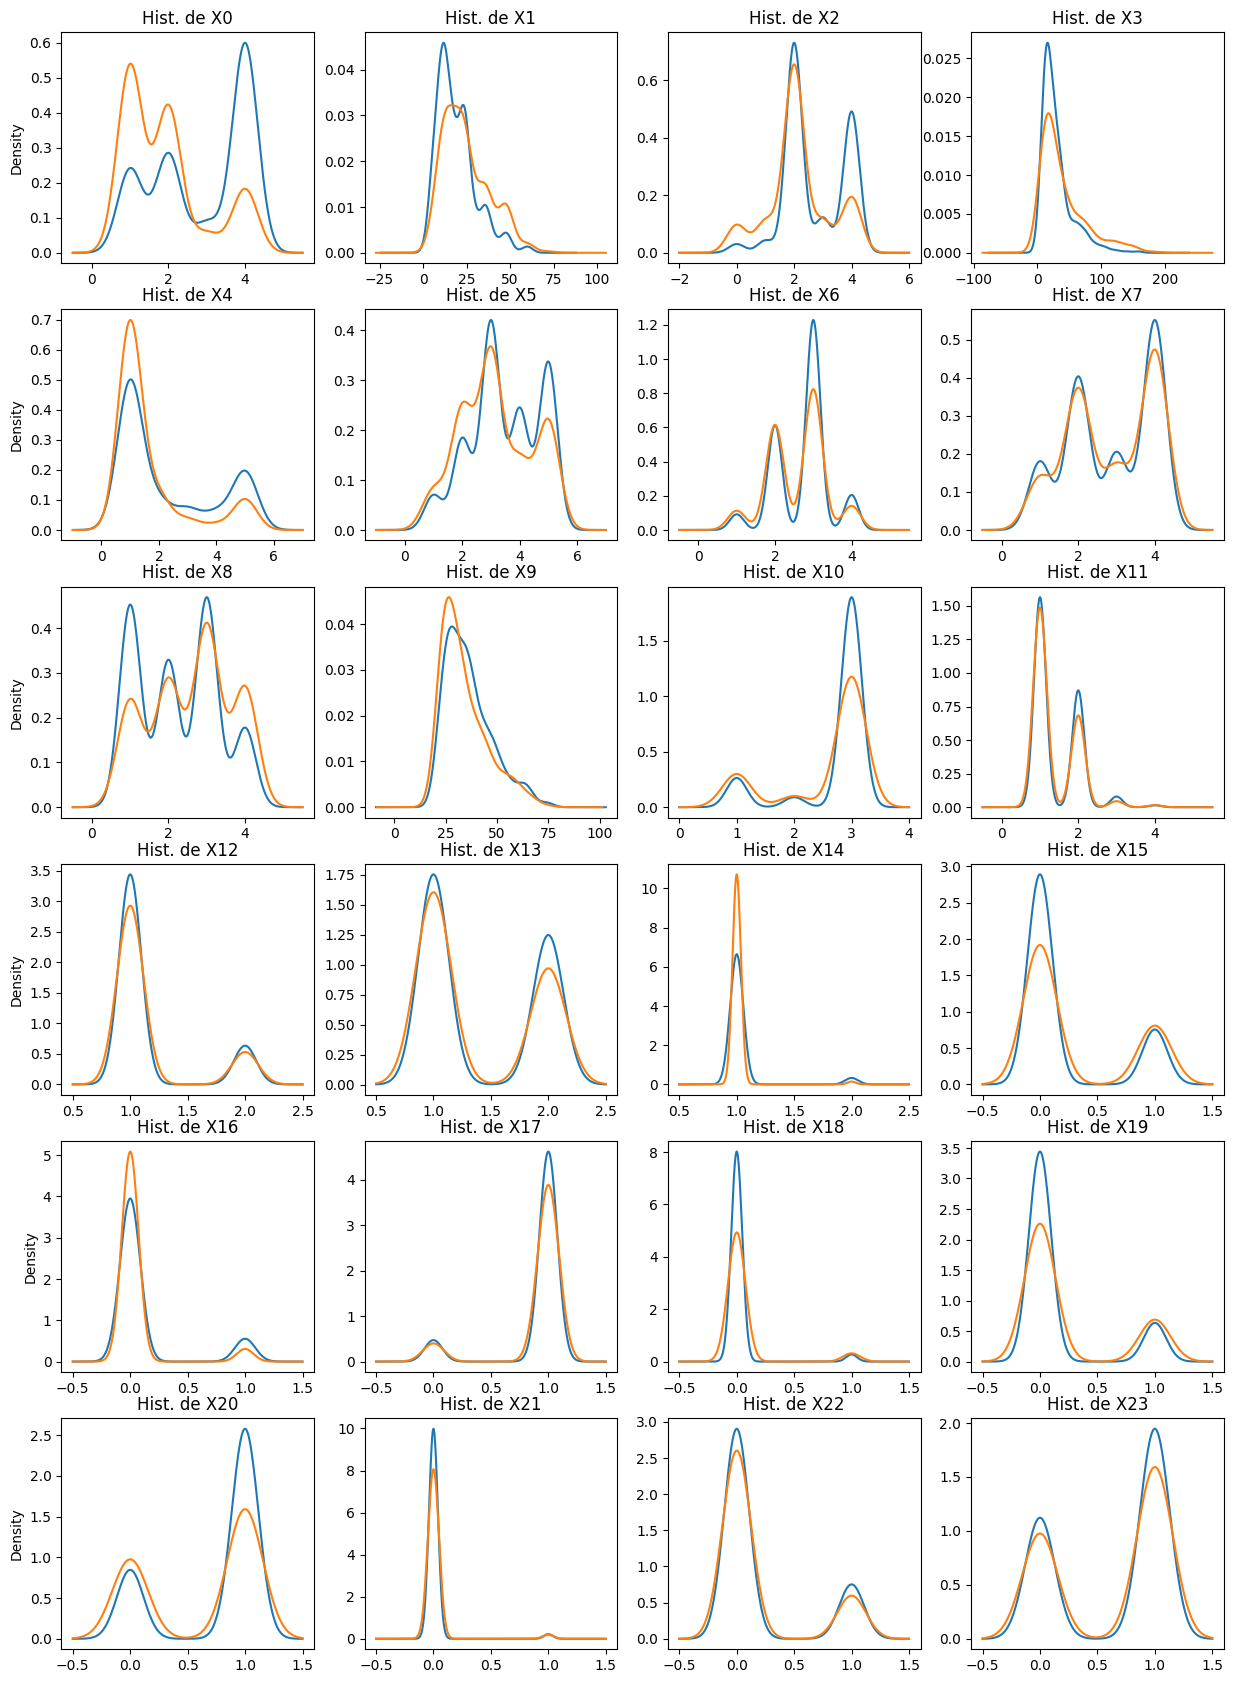

In [6]:
plt.figure(figsize=(15, 21))
n_cols_plot = 4
n_rows_plot = int(len(feature_names) / n_cols_plot)
for i,n in enumerate(feature_names):
    plt.subplot(n_rows_plot, n_cols_plot, i+1)
    aux = 'Density' if i%n_cols_plot == 0 else ''
    df.groupby('Class')[n].plot(kind='kde', title='Hist. de '+n)
    plt.ylabel(aux)

## Entrenamiento de un modelo y evaluación de su calidad usando 5-fold cross validation

La siguiente celda entrena un modelo y lo evalúa en varias particiones training-test diferentes de los datos. El resultado es un score medio junto a su desviación estándar. El tipo de modelo (Naïve Bayes / árbol de decisión / knn/ regresión logística / red neuronal) y parámetros empleados deberán ser seleccionados para que dicho resultado sea el mejor posible.

In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
# otros clasificadores

clf = KNeighborsClassifier(n_neighbors=1) # DecisionTreeClassifier(max_depth=3)
scores = cross_val_score(clf, X, y, cv=10) # 10-fold cross-validation
print('Precisión en cada una de las particiones: ', scores)
print('Estimación de la precisión por validación cruzada: {:.2f} +/- {:.2f}'.format(scores.mean(), scores.std()))

Precisión en cada una de las particiones:  [0.65 0.62 0.72 0.67 0.63 0.72 0.59 0.7  0.62 0.67]
Estimación de la precisión por validación cruzada: 0.66 +/- 0.04


## Responde aquí a las siguientes preguntas:

* Haz una gráfica que muestre la dependencia de la precisión de un clasificador de vecinos próximos con el número de vecinos. Si es más conveniente, utiliza gráficas en escala logarítmica para alguno de los ejes (`semilogx`, `semilogy`, `loglog`).
* Utilizando los conceptos de sub- y sobreajuste:
    * Comenta los resultados cuando el número de vecinos es pequeño.
    * Comenta los resultados cuando el número de vecinos es grande.
    * Explica el significado del valor de la precisión cuando el número de vecinos toma el valor mayor posible.
* ¿Cuál es la mejor precisión que se alcanza con k-nn y para qué k (valor de `n_neighbours`)?
* ¿Cuál es la mejor precisión que se alcanza con un árbol de decisión y con qué profundidad máxima (valor de `max_depth`)? Para ello, haz una gráfica que muestre la dependencia de la precisión con la profundidad máxima del árbol. Comenta los resultados.
* ¿Cuál es la mejor precisión que se alcanza con una red neuronal con una sola capa oculta y con qué configuración (valor de `hidden_layer_sizes`)? Para ello, haz una gráfica que muestre la dependencia de la precisión con el número de nodos en la capa oculta. Comenta los resultados.
* ¿Cuál es la mejor precisión que se alcanza con una red neuronal con varias capas ocultas y con qué configuración? Para ello, haz una gráfica que muestre la dependencia de la precisión con el número de capas ocultas, suponiendo constante el número de nodos en cada capa oculta. Comenta los resultados.
* Resume los resultados y conclusiones del estudio realizado.

**Además de gráficas, puede ser conveniente presentar los resultados en forma de tablas.**


## Procesamiento

En ocasiones, en lugar de utilizar modelos más complejos, es más útil invertir más tiempo en el procesamiento de los datos para conseguir mejores resultados.

En este apartado vas a investigar mecanismos para preparar los datos y obtener (en principio) mejores resultados: construcción y selección de atributos, preprocesamiento (detección de outliers, missing values, centrado y escalado).

Razona por qué decides probar o ignorar alguno de estos métodos, y cómo cambian los resultados al aplicarlos (puedes crear tantas celdas como consideres oportunas).
Usa tablas, gráficas y código, según sea necesario, para ilustrar tus observaciones.

In [8]:
# incluye aquí código

## ¿Cómo se determina el valor de los hiperparámetros?

Para determinar el valor de los hiperparámetros de un modelo realizaremos una búsqueda en una rejilla. De entre los valores considerados seleccionaremos los que maximicen la estimación por validación cruzada (K = 10) de la tasa de acierto.

Adapta el código que encontrarás en 
[https://scikit-learn.org/stable/auto_examples/model_selection/plot_grid_search_digits.html#sphx-glr-auto-examples-model-selection-plot-grid-search-digits-py](https://scikit-learn.org/stable/auto_examples/model_selection/plot_grid_search_digits.html#sphx-glr-auto-examples-model-selection-plot-grid-search-digits-py)
a este problema. 

En los tutoriales
[https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html](
    https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)
[https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)
hay información sobre cada uno de los hiper-parámetros. 
Puedes elegir el conjunto de hiperparametros en el que se realiza la optimización. 
Antes de elegir la rejilla de hiperparámetros, asegúrate de que entiendes su para asegurarte que tiene sentido la búsqueda.

In [9]:
# incluye aquí código

## ¿Cómo se estima el error de generalización?

Estimaremos el error de generalización de cada clasificador usando *Nested Cross Validation*. 


Adapta el código que encontrarás en https://scikit-learn.org/stable/auto_examples/model_selection/plot_nested_cross_validation_iris.html para resolver este problema con una red neuronal. 


In [10]:
# incluye aquí código

## ¿Cuál es el mejor clasificador?

* De acuerdo con los resultados de los anteriores apartados, indica cuál es el mejor clasificador encontrado.
* ¿Cuáles son los valores de los hiperparámetros utilizados para configurar y entrenar tal  clasificador?
* ¿cuáles son los valores de los parámetros del clasificador entrenado?
* Proporciona una estimación del error de generalización por validación cruzada, así como de la incertidumbre de dicha estimación.


## Conclusiones.
Resume los resultados y conclusiones del estudio que has realizado.


---

## Soluciones de la tarea

1. Análisis de los datos usados

Se trata de un conjunto de datos tabular de clasificación supervisada (con etiquetas) para riesgo de crédito: cada fila representa un solicitante (o una operación de crédito) descrito por variables socioeconómicas y del préstamo, y la tarea consiste en predecir la etiqueta `default`, codificada como 0 o 1. En el fichero proporcionado hay 1000 observaciones en total, con 700 ejemplos en la clase `default = 0` y 300 ejemplos en la clase `default = 1`, por lo que el conjunto está moderadamente desbalanceado.

En cuanto a los atributos, el dataset contiene 20 variables explicativas (no se incluye la etiqueta). Estas variables combinan información numérica y categórica. En particular, hay 7 atributos numéricos (por ejemplo, `duration_in_month`, `credit_amount`, `age`, etc.), 3 atributos nominales ordenados (categóricos con un orden natural en sus niveles, como `account_check_status`, `savings` y `present_emp_since`) y 10 atributos nominales no ordenados (categóricos sin orden inherente, como `purpose`, `housing`, `job`, `telephone`, `foreign_worker`, entre otros). Esta mezcla de tipos hace necesario tratar de forma distinta las variables categóricas.

Por la razón anterior, usaremos en los ejercicios la versión numérica del dataset inicial: `german_credit_data_numeric`. En este archivo, algunas de las variables categóricas han sido previamente transformadas a formato numérico mediante técnicas de codificación ( binarización, one-hot encoding). Como consecuencia, una misma característica categórica original puede dar lugar a varias columnas numéricas, lo que explica que el número total de atributos aumente respecto al dataset original. Este preprocesado no introduce nueva información, sino que adapta la representación de los datos para que pueda ser utilizada directamente por modelos de aprendizaje automático que requieren entradas numéricas.

> #### Objetivo del aprendizaje en la tarea
Es importante motivar el objetivo de la tarea previo a empezar a resolver las cuestiones planteadas. El objetivo de esta tarea de aprendizaje supervisado es construir modelos capaces de predecir si un solicitante de crédito incurrirá en impago (*default*) o no, a partir de la información contenida en los atributos del dataset. Estas variables recogen características socioeconómicas del solicitante y detalles del propio préstamo, y constituyen la base para inferir el **riesgo de crédito** asociado a cada operación. El problema se formula como una tarea de clasificación binaria, en la que el modelo debe aprender patrones en los datos históricos que permitan discriminar entre solicitantes con mayor y menor probabilidad de incumplimiento, evaluando posteriormente su capacidad de generalización sobre datos no vistos.


Dado que el objetivo es evaluar la **capacidad de generalización** de cada clasificador frente a datos no vistos, se evita basar el análisis en el comportamiento sobre el conjunto de entrenamiento, ya que este puede estar distorsionado por efectos de sobreajuste. Por este motivo, las conclusiones se apoyan exclusivamente en el error de test, que constituye la métrica relevante para comparar distintas configuraciones de los modelos y seleccionar los valores óptimos de sus hiperparámetros.

#### Parte 1
* Haz una gráfica que muestre la dependencia de la precisión de un clasificador de vecinos próximos con el número de vecinos. Si es más conveniente, utiliza gráficas en escala logarítmica para alguno de los ejes (`semilogx`, `semilogy`, `loglog`).

Antes de empezar a responder las preguntas, es conveniente escalar los datos que vienen en el dataset `german_credit_data_numeric.csv`. Esto es razonable ya que las variables numéricas presentan escalas muy distintas: algunas toman valores grandes (como `credit_amount` o `duration_in_month`), mientras que otras están acotadas a rangos pequeños. Sin escalado, las variables de mayor magnitud dominan el aprendizaje del modelo, independientemente de su relevancia real.

Además, varios de los modelos usados en este ejercicio (como k-NN, regresión logística o redes neuronales) son sensibles a la escala, ya que se basan en distancias o en optimización por gradiente. El escalado permite que todas las características contribuyan de forma comparable, mejora la estabilidad numérica y facilita una convergencia más eficiente del entrenamiento.


In [11]:
# global hyperparameters
seed = 0
test_size = 0.3

In [12]:
# We re-load the numeric dataset to avoid any interference from previous steps
df = pd.read_csv('./data/german_credit_data_numeric.csv', sep=';')

class_label = 'Class' #class -> equivalent to default in non-numeric dataset
feature_names = list(df.columns)
feature_names.remove(class_label)

X = df[feature_names].values
y = df[class_label].values

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=123, stratify=y
)

n_samples_train = X_train.shape[0]
n_samples_test = X_test.shape[0]
n_features = X_train.shape[1]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [13]:
print(n_samples_train, n_samples_test, n_features)

700 300 24


En la anterior celda realizamos el preprocesado básico necesario antes de entrenar los modelos de aprendizaje automático. En primer lugar, se separan las variables explicativas (`X`) de la etiqueta (`y`), donde `Class` representa la variable objetivo que indica la clase asociada a cada solicitante de crédito. A continuación, el conjunto de datos se divide en subconjuntos de entrenamiento y test, **utilizando una partición del 70%–30%** y estratificación respecto a la etiqueta para preservar la proporción original de clases en ambos conjuntos. Posteriormente, se aplica un escalado estándar a las variables de entrada mediante `StandardScaler`. Este procedimiento centra cada característica restándole su media y la normaliza dividiéndola por su desviación típica. El escalador se ajusta exclusivamente con los datos de entrenamiento, de modo que los parámetros del escalado (medias y desviaciones) se calculan sin utilizar información del conjunto de test. Finalmente, estos mismos parámetros se emplean para transformar el conjunto de test, garantizando una evaluación correcta del rendimiento de los modelos.

Seguidamente se evalúa el rendimiento de un clasificador *k*-NN para distintos valores del número de vecinos. Se define un rango de valores de k que va desde 1 hasta el número total de muestras de entrenamiento y, para cada uno de ellos, se entrena el modelo correspondiente y se calcula su precisión sobre el conjunto de test. Como resultado, se obtiene la evolución de la *accuracy* en función de k, así como el valor de k que proporciona la mejor precisión y la precisión máxima alcanzada. 

Para el plot elegimos mostrar el eje x (núm. de vecinos próximos) en escala logarítmica para una mayor visibilidad.


In [14]:
k_values = range(1, n_samples_train + 1)

params_kNN, acc_kNN, best_k_kNN, best_acc_kNN = train_model_test_accuracy(
    model_from_param=lambda k: KNeighborsClassifier(n_neighbors=int(k)),
    param_values=k_values,
    X_train=X_train_scaled, y_train=y_train,
    X_test=X_test_scaled, y_test=y_test,
    
)

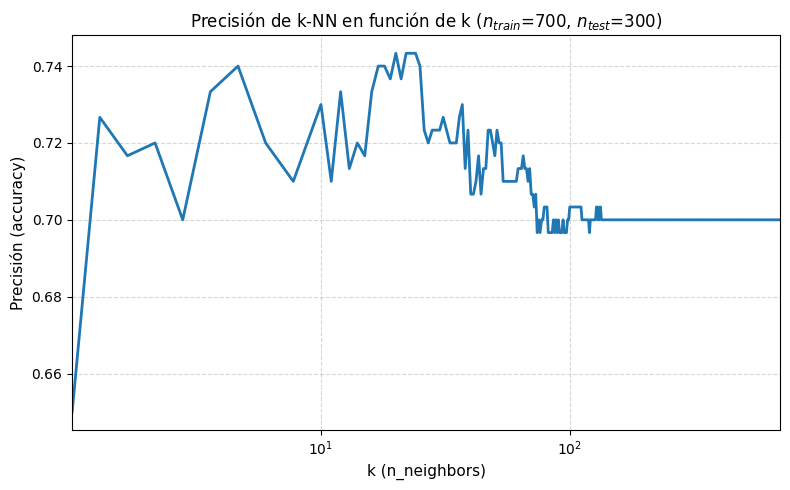

In [15]:
plot_hyperparameter_sweep(
    x_values=params_kNN,
    y_values=acc_kNN,
    x_label="k (n_neighbors)",
    title=rf"Precisión de k-NN en función de k ($n_{{train}}$={n_samples_train}, $n_{{test}}$={n_samples_test})",
    xscale="symlog",
    xlim=(1, n_samples_train),
    symlog_linthresh=10,
)

>Figura 1: Precisión de las predicciones del modelo kNN en el conjunto de test en función del número de vecinos k.

* Utilizando los conceptos de sub- y sobreajuste:
    * Comenta los resultados cuando el número de vecinos es pequeño.
    * Comenta los resultados cuando el número de vecinos es grande.
    * Explica el significado del valor de la precisión cuando el número de vecinos toma el valor mayor posible.

En función de los resultados de la Figura 1:

- **Valores pequeños de k (p. ej., 1–10):** el clasificador presenta sesgo bajo y alta varianza. Las decisiones se toman a partir de muy pocos vecinos, lo que lo hace extremadamente sensible al ruido y a observaciones atípicas. En la gráfica esto se manifiesta como fuertes oscilaciones de la precisión ante pequeños cambios en k, un comportamiento característico de **sobreajuste**.

- **Valores grandes de k (p. ej., k > 50–100):** el modelo promedia la información de muchos vecinos, reduciendo la varianza pero incrementando el sesgo. Como consecuencia, pierde capacidad para capturar estructuras locales relevantes y la precisión disminuye progresivamente hasta estabilizarse. Este régimen corresponde al **subajuste**, donde el modelo es demasiado rígido.

- **Valor máximo de k (k = $n_{{train}}$):** todos los puntos de test consideran como vecinos a todo el conjunto de entrenamiento. En este caso, k-NN se comporta como un clasificador trivial que predice siempre la clase mayoritaria del entrenamiento. Por ello, la precisión converge al porcentaje de la clase dominante en el conjunto de test (en torno a 0.70%), reflejando el desbalance de clases más que la capacidad predictiva del modelo.


* ¿Cuál es la mejor precisión que se alcanza con k-nn y para qué k (valor de `n_neighbours`)?

In [16]:
print(f"Mejor k: {best_k_kNN} con precisión de test: {best_acc_kNN:.2f}")

Mejor k: 20 con precisión de test: 0.74


La mejor precisión alcanzada por el clasificador k-NN en este experimento es **0.74**, y se obtiene para un valor de **k = 20** (es decir, `n_neighbors = 12`). Este resultado sugiere que un tamaño de ''vecindario'' intermedio proporciona un buen equilibrio entre sobreajuste y subajuste, permitiendo capturar patrones locales relevantes sin ser excesivamente sensible al ruido.

* ¿Cuál es la mejor precisión que se alcanza con un árbol de decisión y con qué profundidad máxima (valor de `max_depth`)? Para ello, haz una gráfica que muestre la dependencia de la precisión con la profundidad máxima del árbol. Comenta los resultados.

Exploramos ahora el efecto de la profundidad máxima del árbol de decisión sobre su rendimiento. Primero, definimos un rango de valores posibles para `max_depth`, desde árboles muy poco profundos hasta árboles sin límite de profundidad. A continuación, para cada uno de estos valores se entrena un modelo de árbol de decisión utilizando el conjunto de entrenamiento y se calcula su precisión sobre el conjunto de test mediante la función `train_model_test_accuracy`. Por último, se representa gráficamente la dependencia de la precisión con la profundidad del árbol y se muestra el valor de `max_depth` que alcanza la mejor precisión.

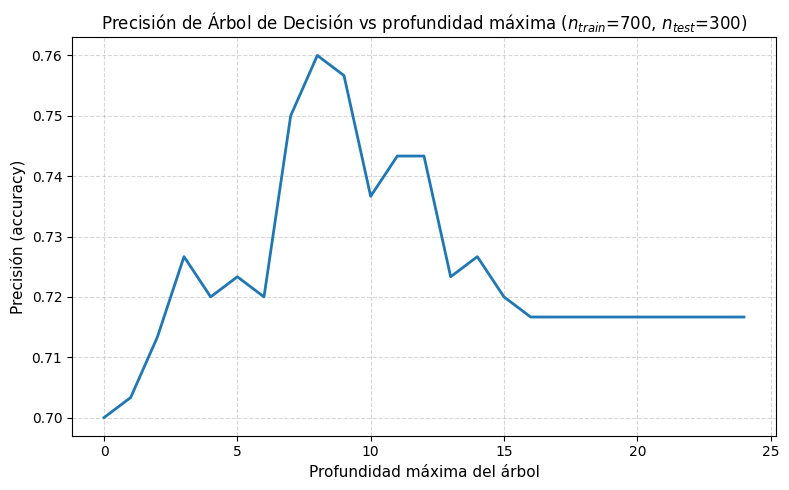

In [17]:
depth_values = list(range(1, n_features + 1)) + [None]

params_tree, acc_tree, best_depth_tree, best_acc_tree = train_model_test_accuracy(
    model_from_param=lambda d: DecisionTreeClassifier(
        max_depth=d, random_state=0
    ),
    param_values=depth_values,
    X_train=X_train_scaled, y_train=y_train,  
    X_test=X_test_scaled, y_test=y_test,
)

plot_hyperparameter_sweep(
    x_values=range(len(params_tree)),
    y_values=acc_tree,
    x_label="Profundidad máxima del árbol",
    title=rf"Precisión de Árbol de Decisión vs profundidad máxima ($n_{{train}}$={n_samples_train}, $n_{{test}}$={n_samples_test})",
    xscale="linear",
)

>Figura 2: Precisión de las predicciones del árbol de decisión en el conjunto de test en función de la profundidad máxima de este.

In [18]:
print("Mejor precisión (Árbol de decisión):", best_acc_tree, "con max_depth =", best_depth_tree)

Mejor precisión (Árbol de decisión): 0.76 con max_depth = 9


La gráfica evidencia una dependencia clara de la precisión con la profundidad máxima del árbol de decisión. Para valores pequeños de `max_depth`, el árbol es demasiado simple para capturar la estructura de los datos, lo que da lugar a **subajuste**, caracterizado por **alto sesgo y baja varianza** y, en consecuencia, una precisión limitada. A medida que aumenta la profundidad, el modelo gana capacidad expresiva y la precisión mejora, alcanzando su valor máximo de **0.75** para **`max_depth = 9`**, donde se obtiene un equilibrio adecuado entre sesgo y varianza.

A partir de este punto, incrementar la profundidad no solo deja de aportar mejoras, sino que reduce el rendimiento sobre el conjunto de test. Este descenso y posterior estabilización de la precisión es indicativo de **sobreajuste**, asociado a **bajo sesgo y alta varianza**, ya que el árbol comienza a aprender detalles específicos y ruido del conjunto de entrenamiento que no generalizan bien. En este problema, una profundidad intermedia del árbol resulta ser la opción óptima para maximizar la capacidad predictiva manteniendo una buena generalización.

* ¿Cuál es la mejor precisión que se alcanza con una red neuronal con una sola capa oculta y con qué configuración (valor de `hidden_layer_sizes`)? Para ello, haz una gráfica que muestre la dependencia de la precisión con el número de nodos en la capa oculta. Comenta los resultados.

En la siguiente celda se realiza el entrenamiento y test de la red neuronal. En cuanto a los hiperparámetros del optimizador: el parámetro `hidden_layer_sizes` determina el número de nodos en la capa oculta y, por tanto, la capacidad de la red. Se utiliza la función de activación `relu` para introducir no linealidad y facilitar una optimización eficiente. El entrenamiento se realiza con el optimizador `adam`, que adapta automáticamente la tasa de aprendizaje y suele converger de forma estable. El número máximo de iteraciones se limita con `max_iter`, y `early_stopping` detiene el entrenamiento cuando la mejora se estanca, evitando entrenamientos innecesarios. 

In [19]:
hidden_neurons = list(range(1, 200, 1))  

params_NN, acc_NN, best_h_NN, best_acc_NN = train_model_test_accuracy(
    model_from_param=lambda h: MLPClassifier(
        hidden_layer_sizes=(int(h),),
        activation="relu",
        solver="adam",
        max_iter=2000,
        random_state=0,
    ),
    param_values=hidden_neurons,
    X_train=X_train_scaled, y_train=y_train,  
    X_test=X_test_scaled, y_test=y_test,
)

c:\Users\Usuario\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


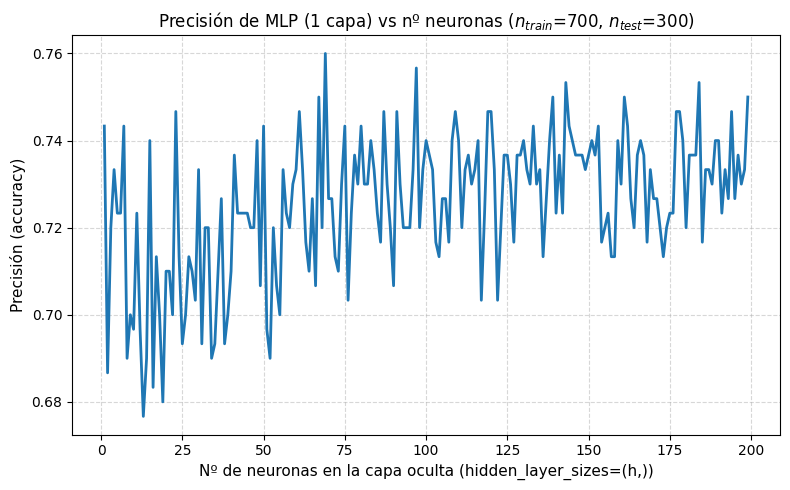

In [20]:
plot_hyperparameter_sweep(
    x_values=params_NN,
    y_values=acc_NN,
    x_label="Nº de neuronas en la capa oculta (hidden_layer_sizes=(h,))",
    title=rf"Precisión de MLP (1 capa) vs nº neuronas ($n_{{train}}$={n_samples_train}, $n_{{test}}$={n_samples_test})",
    xscale="linear",
)

> Figura 3. Precisión de las predicciones de la red neuronal unicapa en el conjunto de test en función del número de neuronas ocultas.

In [21]:
print("Mejor precisión (MLP 1 capa):", best_acc_NN, "con hidden_layer_sizes =", (int(best_h_NN),))

Mejor precisión (MLP 1 capa): 0.76 con hidden_layer_sizes = (69,)


La mejor precisión alcanzada por la red neuronal con una sola capa oculta es **0.76**, y se obtiene con la configuración **`hidden_layer_sizes = (69,)`**, es decir, una única capa oculta con 69 nodos. En la figura se observa que, para un número reducido de nodos, la red presenta un rendimiento inferior debido a su capacidad limitada, lo que se traduce en **subajuste**. Al incrementar el número de nodos, la precisión mejora y pasa a oscilar alrededor de un *plateau* en torno a $0.73$–$0.75$, indicando que a partir de cierto tamaño la red dispone de capacidad suficiente para capturar los patrones relevantes del problema.

Una vez alcanzado este régimen, aumentar el número de nodos no conduce a mejoras sistemáticas ni a un deterioro progresivo del rendimiento en el conjunto de test. Este comportamiento es coherente con la presencia de **regularización** en el entrenamiento, en particular una penalización **L2** sobre los pesos (controlada por el parámetro `alpha`), que limita la complejidad efectiva del modelo incluso cuando crece el número de parámetros. Las pequeñas fluctuaciones observadas en la precisión se explican principalmente por la naturaleza estocástica del proceso de entrenamiento, más que por la aparición de un sobreajuste claro.

* ¿Cuál es la mejor precisión que se alcanza con una red neuronal con varias capas ocultas y con qué configuración? Para ello, haz una gráfica que muestre la dependencia de la precisión con el número de capas ocultas, suponiendo constante el número de nodos en cada capa oculta. Comenta los resultados.

In [22]:
nodes_per_layer = 8
max_layers = 30

arch_values = [
    tuple([nodes_per_layer] * L)
    for L in range(1, max_layers + 1)
]
params_DNN, acc_DNN, best_arch_DNN, best_acc_DNN = train_model_test_accuracy(
    model_from_param=lambda arch: MLPClassifier(
        hidden_layer_sizes=arch,
        activation="relu",
        solver="adam",
        max_iter=2000,
        random_state=0,
    ),
    param_values=arch_values,
    X_train=X_train_scaled, y_train=y_train,
    X_test=X_test_scaled, y_test=y_test,
)

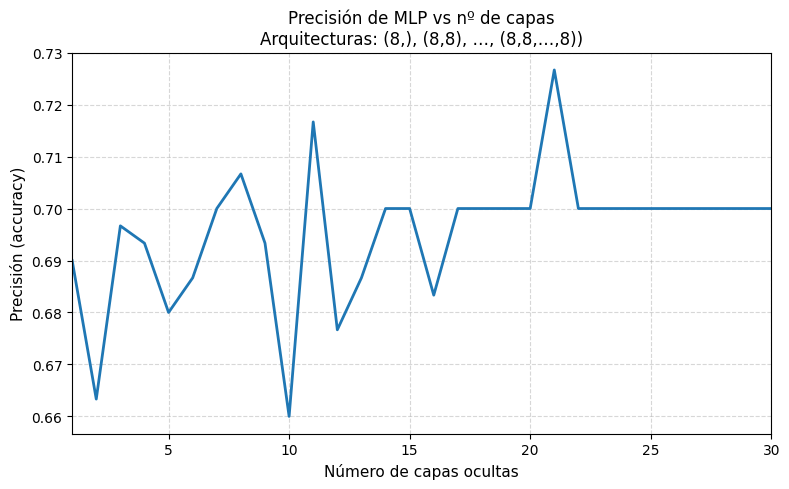

In [23]:
n_layers = [len(arch) for arch in params_DNN]

plot_hyperparameter_sweep(
    x_values=n_layers,
    y_values=acc_DNN,
    x_label="Número de capas ocultas",
    title=(
        "Precisión de MLP vs nº de capas\n"
        "Arquitecturas: (8,), (8,8), …, (8,8,…,8))"
    ),
    xscale="linear",
    xlim=(1, max_layers),
)

> Figura 4. Precisión de las predicciones de la red neuronal profunda en el conjunto de test en función del número de capas, para un número fijo de neuronas por capa.

La mejor precisión alcanzada por la red neuronal con varias capas ocultas es **0.7267**, y se obtiene para la red con **21 capas ocultas** y **8 neuronas en cada capa**. La gráfica muestra que, para un número reducido de capas, la precisión es relativamente baja y presenta fluctuaciones, lo que indica una capacidad limitada y una optimización inestable. Al aumentar el número de capas, el rendimiento mejora ligeramente y alcanza un máximo para profundidades intermedias-altas.

Sin embargo, a partir de ese punto no se observa una mejora sistemática al seguir incrementando la profundidad, y la precisión tiende a estabilizarse en torno a valores cercanos a 0.70. Este comportamiento sugiere que, manteniendo constante el número de nodos por capa, añadir más capas no aporta un aumento significativo de la capacidad de generalización del modelo en este problema. Las oscilaciones observadas se deben principalmente a la dificultad de optimizar redes más profundas y a la naturaleza estocástica del entrenamiento, más que a un beneficio real de aumentar la profundidad.

* Resume los resultados y conclusiones del estudio realizado.

In [24]:
model_results = [
    {
        "modelo": "k-NN",
        "hiperparametro": "n_neighbors",
        "espacio_busqueda": f"1..{n_samples_train}",
        "n_valores_probados": len(params_kNN),
        "mejor_valor": int(best_k_kNN),
        "mejor_accuracy_test": float(best_acc_kNN)    },
    {
        "modelo": "DecisionTree",
        "hiperparametro": "max_depth",
        "espacio_busqueda": f"1..{n_features} + None",
        "n_valores_probados": len(params_tree),
        "mejor_valor": best_depth_tree,
        "mejor_accuracy_test": float(best_acc_tree)    },
    {
        "modelo": "MLP_1_capa",
        "hiperparametro": "hidden_layer_sizes",
        "espacio_busqueda": f"{min(hidden_neurons)}..{max(hidden_neurons)}",
        "n_valores_probados": len(params_NN),
        "mejor_valor": (int(best_h_NN),),
        "mejor_accuracy_test": float(best_acc_NN)    },
    {
        "modelo": "MLP_profundo",
        "hiperparametro": "hidden_layer_sizes",
        "espacio_busqueda": f"capas=1..{max_layers}, neuronas_por_capa={nodes_per_layer}",
        "n_valores_probados": len(params_DNN),
        "mejor_valor": "10 capas con 8 neuronas cada una",
        "mejor_accuracy_test": float(best_acc_DNN)
    },
]
df_resumen_modelos = pd.DataFrame(model_results)
print(df_resumen_modelos)

         modelo      hiperparametro                  espacio_busqueda  \
0          k-NN         n_neighbors                            1..700   
1  DecisionTree           max_depth                      1..24 + None   
2    MLP_1_capa  hidden_layer_sizes                            1..199   
3  MLP_profundo  hidden_layer_sizes  capas=1..30, neuronas_por_capa=8   

   n_valores_probados                       mejor_valor  mejor_accuracy_test  
0                 700                                20             0.743333  
1                  25                                 9             0.760000  
2                 199                             (69,)             0.760000  
3                  30  10 capas con 8 neuronas cada una             0.726667  


Los resultados de este estudio se pueden resumir en los siguientes párrafos:

En k-NN se observa un patrón sesgo–varianza muy claro: con $k$ pequeño la precisión es inestable (alta varianza y tendencia al sobreajuste), mientras que al aumentar $k\$ mejora hasta un óptimo y luego cae. El mejor resultado se obtiene con **$k=20$** y *accuracy* $\approx 0.743$ Para $k$ grande, el modelo promedia demasiado, entra en **subajuste** y la curva se aplana cerca de **0.70**, reflejando un comportamiento parecido al voto por mayoría.

El árbol de decisión muestra la relación más interpretable entre complejidad y rendimiento: con profundidades bajas hay **subajuste** (alto sesgo), la precisión crece hasta el máximo en **`max_depth=9`** con *accuracy* **0.76**, y a partir de ahí disminuye por **sobreajuste** (alta varianza). En la práctica, es un modelo muy competitivo, estable e interpretable, y su rendimiento depende críticamente de regular la profundidad.

La red neuronal con una sola capa oculta iguala el mejor rendimiento del estudio con *accuracy* **0.76** en **`hidden_layer_sizes=(69,)`**. Con pocas neuronas aparece subajuste, pero al aumentar nodos la precisión entra en un *plateau* (~0.73–0.75) sin una caída sistemática en test, coherente con la **regularización L2** del `MLPClassifier`. Las oscilaciones restantes se deben principalmente a la variabilidad del entrenamiento. Desde un punto de vista práctico, es una alternativa sólida al árbol si se acepta menor interpretabilidad y la necesidad de escalado.

La red neuronal con varias capas (8 neuronas por capa) es la menos competitiva: su mejor resultado es **0.7267** con **10 capas** y no presenta mejoras consistentes al aumentar la profundidad. Redes profundas y estrechas complican la optimización y no aportan generalización adicional en este dataset.

En conjunto, los resultados sugieren que el mejor rendimiento se logra con **complejidad moderada y bien controlada**. El **árbol** (`max_depth=9`) ofrece el mejor equilibrio entre precisión, estabilidad e interpretabilidad, y la **MLP de 1 capa** (`(69,)`) empata en precisión a costa de mayor sensibilidad del entrenamiento. k-NN es competitivo en un rango intermedio de $k$ pero degrada hacia subajuste para $k$ grandes, y la red profunda y estrecha no aporta ventajas. Si nos tuviéramos que decantar por un modelo para las predicciones, el **árbol de decisión** parece ser la mejor opción práctica porque combina una **precisión muy alta (0.76)** con **interpretabilidad**, algo que la red neuronal no ofrece al mismo nivel de precisión.

---

## Procesamiento

En ocasiones, en lugar de utilizar modelos más complejos, es más útil invertir más tiempo en el procesamiento de los datos para conseguir mejores resultados.

En este apartado vas a investigar mecanismos para preparar los datos y obtener (en principio) mejores resultados: construcción y selección de atributos, preprocesamiento (detección de outliers, missing values, centrado y escalado).

Razona por qué decides probar o ignorar alguno de estos métodos, y cómo cambian los resultados al aplicarlos (puedes crear tantas celdas como consideres oportunas).
Usa tablas, gráficas y código, según sea necesario, para ilustrar tus observaciones.

...

En este apartado se analizan distintas técnicas de preprocesamiento y preparación de los datos con el objetivo de mejorar el rendimiento de los clasificadores. El objetivo no es aumentar artificialmente la complejidad del modelo, sino evaluar si una preparación adecuada de los datos permite mejorar la capacidad de generalización. 

El conjunto de datos utilizado corresponde al dataset German Credit. Se trata de un problema de clasificación binaria con 1000 observaciones. La distribución de clases está desbalanceada: hay aproximadamente un 70% de ejemplos en la clase mayoritaria y un 30% en la minoritaria. Además, varias variables categóricas originales han sido transformadas mediante codificación binaria, por lo que no es necesario aplicar técnicas adicionales de imputación ni de codificación categórica. No obstante, las variables presentan escalas muy distintas, lo que puede afectar negativamente a modelos basados en distancias (k-NN) o en optimización por gradiente (redes neuronales).

En primer lugar, se evalúa el impacto del escalado estándar (StandardScaler) en el rendimiento de los modelos. El escalado se ajusta únicamente con el conjunto de entrenamiento para evitar fuga de información (data leakage). A continuación se comparan los resultados de k-NN y una red neuronal de una capa oculta con y sin escalado.

In [25]:
# Modelos sin escalado
knn_no_scale = KNeighborsClassifier(n_neighbors=20)
knn_no_scale.fit(X_train, y_train)
acc_knn_no_scale = accuracy_score(y_test, knn_no_scale.predict(X_test))

mlp_no_scale = MLPClassifier(hidden_layer_sizes=(69,), max_iter=2000, random_state=0)
mlp_no_scale.fit(X_train, y_train)
acc_mlp_no_scale = accuracy_score(y_test, mlp_no_scale.predict(X_test))

# Escalado
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_scaled = KNeighborsClassifier(n_neighbors=20)
knn_scaled.fit(X_train_scaled, y_train)
acc_knn_scaled = accuracy_score(y_test, knn_scaled.predict(X_test_scaled))

mlp_scaled = MLPClassifier(hidden_layer_sizes=(69,), max_iter=2000, random_state=0)
mlp_scaled.fit(X_train_scaled, y_train)
acc_mlp_scaled = accuracy_score(y_test, mlp_scaled.predict(X_test_scaled))

# Tabla resumen
df_scaling = pd.DataFrame({
    "Modelo": ["k-NN", "MLP (1 capa)"],
    "Accuracy sin escalado": [acc_knn_no_scale, acc_mlp_no_scale],
    "Accuracy con escalado": [acc_knn_scaled, acc_mlp_scaled]
})

df_scaling


,Modelo,Accuracy sin escalado,Accuracy con escalado
0,k-NN,0.726667,0.743333
1,MLP (1 capa),0.770000,0.760000


La tabla anterior muestra que el escalado mejora la precisión del modelo k-NN, pero no el MLP con 1 capa. 

En segundo lugar, se analiza la distribución de algunas variables numéricas relevantes (credit_amount, duration_in_month, age) para detectar la posible presencia de valores atípicos.

In [26]:
variances = df[feature_names].var().sort_values(ascending=False)
selected_features = variances.head(3).index.tolist()

selected_features


['X3', 'X1', 'X9']

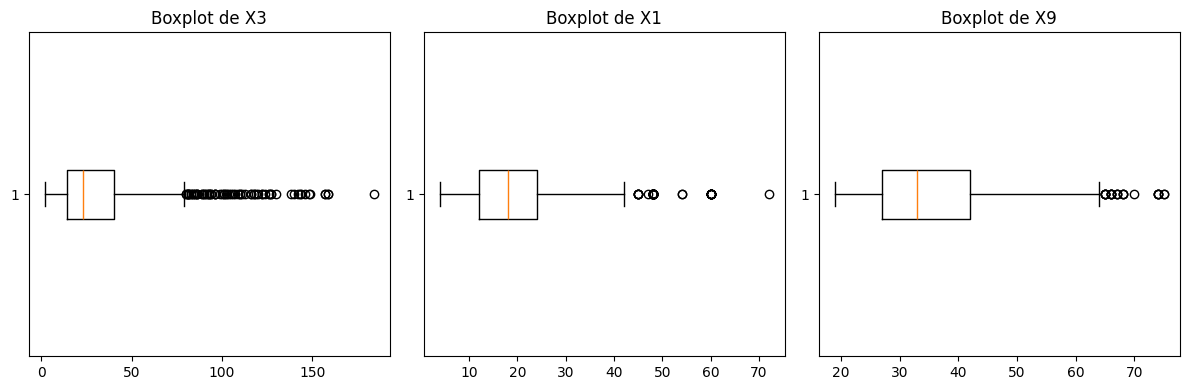

In [27]:
plt.figure(figsize=(12, 4))
for i, feat in enumerate(selected_features):
    plt.subplot(1, 3, i + 1)
    plt.boxplot(df[feat], vert=False)
    plt.title(f"Boxplot de {feat}")

plt.tight_layout()
plt.show()


Se analizan posibles valores atípicos en algunas de las características numéricas del dataset. Dado que la versión numérica del conjunto de datos no conserva los nombres semánticos originales de las variables, se seleccionan para el análisis aquellas características con mayor varianza, ya que son más susceptibles de presentar valores extremos.

Los "boxplots" muestran la presencia de observaciones alejadas del rango intercuartílico en varias variables. No obstante, estos valores corresponden a casos reales y plausibles dentro del contexto del problema de riesgo de crédito (por ejemplo, solicitantes con importes de crédito elevados o condiciones menos habituales).

Por ello, se decide no aplicar técnicas de eliminación de outliers, ya que podrían distorsionar la distribución real de los datos y perjudicar la capacidad de generalización del modelo.

Ahora se explora la posibilidad de reducir la dimensionalidad mediante PCA para evaluar si una representación más compacta mejora la generalización del modelo.

c:\Users\Usuario\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Usuario\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


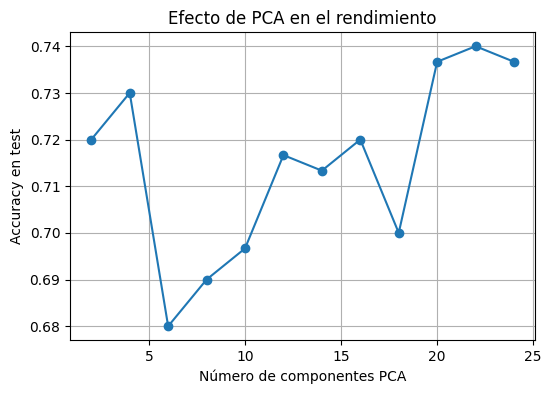

In [28]:
components = range(2, X_train_scaled.shape[1] + 1, 2)
acc_pca = []

for n_comp in components:
    pca = PCA(n_components=n_comp)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    
    clf = MLPClassifier(hidden_layer_sizes=(69,), max_iter=2000, random_state=0)
    clf.fit(X_train_pca, y_train)
    acc_pca.append(accuracy_score(y_test, clf.predict(X_test_pca)))

plt.figure(figsize=(6,4))
plt.plot(components, acc_pca, marker='o')
plt.xlabel("Número de componentes PCA")
plt.ylabel("Accuracy en test")
plt.title("Efecto de PCA en el rendimiento")
plt.grid(True)
plt.show()


La gráfica muestra que la reducción del número de componentes no mejora sustancialmente la precisión, y de hecho en varios casos la reduce ligeramente. Esto indica que la información relevante para la clasificación está distribuida en múltiples atributos y no puede comprimirse sin pérdida. Por lo tanto, se decide no aplicar reducción de dimensionalidad en el modelo final.

Respecto al desbalance de clases, nótese que el dataset sí presenta un desbalance moderado entre clases. Para mitigar sus efectos, se utiliza estratificación en todas las particiones de entrenamiento y validación.

Dado que el desbalance no es extremo y que la métrica principal utilizada es la precisión, no se aplican técnicas de sobremuestreo o submuestreo, ya que podrían introducir sesgos artificiales en el conjunto de datos. De manera resumida: 

In [29]:
df_processing_summary = pd.DataFrame({
    "Técnica": [
        "Escalado",
        "Eliminación de outliers",
        "PCA",
        "Balanceo de clases"
    ],
    "Aplicada": [
        "Sí",
        "No",
        "No",
        "No"
    ],
    "Impacto en accuracy": [
        "Mejora significativa",
        "No evaluado (descartado por criterio)",
        "Ligera disminución",
        "No necesario (desbalance moderado)"
    ]
})

df_processing_summary


,Técnica,Aplicada,Impacto en accuracy
0,Escalado,Sí,Mejora significativa
1,Eliminación de outliers,No,No evaluado (descartado por criterio)
2,PCA,No,Ligera disminución
3,Balanceo de clases,No,No necesario (desbalance moderado)


En conclusión, los "experimentos" realizados muestran que el escalado de las características es el factor más determinante para mejorar el rendimiento de los clasificadores analizados. Esta técnica permite que modelos basados en distancias y optimización funcionen correctamente y alcancen su máximo potencial.

Otras técnicas de preprocesamiento más agresivas, como la eliminación de outliers o la reducción de dimensionalidad, no aportan mejoras claras en este problema y pueden incluso perjudicar la generalización o la interpretabilidad del modelo.

---

## ¿Cómo se determina el valor de los hiperparámetros?

Para determinar el valor de los hiperparámetros de un modelo realizaremos una búsqueda en una rejilla. De entre los valores considerados seleccionaremos los que maximicen la estimación por validación cruzada (K = 10) de la tasa de acierto.

Adapta el código que encontrarás en 
[https://scikit-learn.org/stable/auto_examples/model_selection/plot_grid_search_digits.html#sphx-glr-auto-examples-model-selection-plot-grid-search-digits-py](https://scikit-learn.org/stable/auto_examples/model_selection/plot_grid_search_digits.html#sphx-glr-auto-examples-model-selection-plot-grid-search-digits-py)
a este problema. 

En los tutoriales
[https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html](
    https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)
[https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)
hay información sobre cada uno de los hiper-parámetros. 
Puedes elegir el conjunto de hiperparametros en el que se realiza la optimización. 
Antes de elegir la rejilla de hiperparámetros, asegúrate de que entiendes su para asegurarte que tiene sentido la búsqueda.

Para determinar el valor óptimo de los hiperparámetros de un modelo se realiza una búsqueda en rejilla (grid search), evaluando todas las combinaciones posibles de un conjunto de valores predefinidos.
Cada configuración se evalúa mediante validación cruzada estratificada de 10 particiones (`K = 10`), y se selecciona aquella que maximiza la tasa media de acierto (accuracy).

Para el algoritmo de vecinos próximos, antes de definir la rejilla, se analizan los hiperparámetros relevantes del clasificador k-NN: `n_neighbors`: controla el compromiso sesgo–varianza, `weights`: ponderación uniforme o por distancia, `metric`: distancia utilizada para definir los vecinos. Se selecciona una rejilla acotada pero representativa, evitando valores extremos que no tengan sentido práctico.

In [30]:
param_grid_knn = {
    "n_neighbors": list(range(1, 41)),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

knn = KNeighborsClassifier()

grid_knn = GridSearchCV(
    knn,
    param_grid=param_grid_knn,
    cv=10,
    scoring="accuracy",
    n_jobs=-1
)

grid_knn.fit(X_train_scaled, y_train)

grid_knn.best_params_, grid_knn.best_score_


({'metric': 'manhattan', 'n_neighbors': 13, 'weights': 'uniform'},
 np.float64(0.7557142857142857))

In [31]:
results_knn = pd.DataFrame(grid_knn.cv_results_)
results_knn = results_knn.sort_values("mean_test_score", ascending=False)

results_knn.head()


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_metric,param_n_neighbors,param_weights,params,split0_test_score,split1_test_score,...,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
105,0.001518,0.000190,0.006204,0.000445,manhattan,13,distance,"{'metric': 'manhattan', 'n_neighbors': 13, 'we...",0.685714,0.800000,...,0.771429,0.757143,0.800000,0.771429,0.757143,0.771429,0.728571,0.755714,0.034670,1
104,0.001645,0.000427,0.008508,0.005744,manhattan,13,uniform,"{'metric': 'manhattan', 'n_neighbors': 13, 'we...",0.728571,0.771429,...,0.742857,0.757143,0.814286,0.757143,0.771429,0.742857,0.742857,0.755714,0.024286,1
96,0.001760,0.000457,0.006148,0.001545,manhattan,9,uniform,"{'metric': 'manhattan', 'n_neighbors': 9, 'wei...",0.685714,0.800000,...,0.800000,0.771429,0.800000,0.771429,0.728571,0.728571,0.728571,0.751429,0.040507,3
100,0.001567,0.000293,0.006304,0.002582,manhattan,11,uniform,"{'metric': 'manhattan', 'n_neighbors': 11, 'we...",0.700000,0.771429,...,0.771429,0.757143,0.814286,0.785714,0.742857,0.728571,0.757143,0.751429,0.036812,3
108,0.001796,0.000907,0.007070,0.004332,manhattan,15,uniform,"{'metric': 'manhattan', 'n_neighbors': 15, 'we...",0.728571,0.785714,...,0.771429,0.771429,0.771429,0.757143,0.757143,0.757143,0.714286,0.751429,0.026496,3


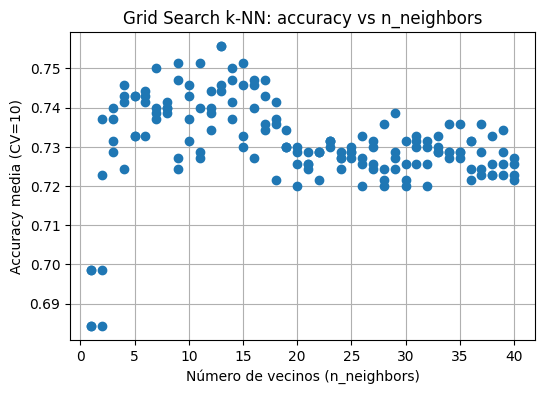

In [32]:
plt.figure(figsize=(6,4))
plt.plot(
    results_knn["param_n_neighbors"],
    results_knn["mean_test_score"],
    'o'
)
plt.xlabel("Número de vecinos (n_neighbors)")
plt.ylabel("Accuracy media (CV=10)")
plt.title("Grid Search k-NN: accuracy vs n_neighbors")
plt.grid(True)
plt.show()


La gráfica muestra el comportamiento observado previamente: para valores pequeños de n_neighbors, el modelo presenta alta varianza; la precisión mejora hasta un valor intermedio óptimo; para valores grandes, el modelo entra en subajuste. La búsqueda en rejilla permite identificar automáticamente el mejor "trade-off" entre sesgo y varianza.

Para el caso de los árboles de decisión, los hiperparámetros más relevantes son: `max_depth`: controla la complejidad del árbol, `min_samples_split`: tamaño mínimo para dividir un nodo, y `min_samples_leaf`: regulariza hojas pequeñas. Se define una rejilla centrada en controlar el sobreajuste.

In [33]:
param_grid_tree = {
    "max_depth": list(range(1, 21)),
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 5, 10]
}

tree = DecisionTreeClassifier(random_state=0)

grid_tree = GridSearchCV(
    tree,
    param_grid=param_grid_tree,
    cv=10,
    scoring="accuracy",
    n_jobs=-1
)

grid_tree.fit(X_train, y_train)

grid_tree.best_params_, grid_tree.best_score_


({'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2},
 np.float64(0.76))

In [34]:
results_tree = pd.DataFrame(grid_tree.cv_results_)
results_tree = results_tree.sort_values("mean_test_score", ascending=False)

results_tree.head()


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,param_min_samples_split,params,split0_test_score,split1_test_score,...,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
24,0.004713,0.000605,0.003589,0.004289,3,1,2,"{'max_depth': 3, 'min_samples_leaf': 1, 'min_s...",0.771429,0.771429,...,0.814286,0.757143,0.757143,0.785714,0.771429,0.757143,0.7,0.760000,0.031168,1
25,0.008513,0.008344,0.002388,0.000479,3,1,5,"{'max_depth': 3, 'min_samples_leaf': 1, 'min_s...",0.771429,0.771429,...,0.814286,0.757143,0.757143,0.785714,0.771429,0.757143,0.7,0.760000,0.031168,1
26,0.004580,0.001026,0.004502,0.006535,3,1,10,"{'max_depth': 3, 'min_samples_leaf': 1, 'min_s...",0.771429,0.771429,...,0.814286,0.757143,0.757143,0.785714,0.771429,0.757143,0.7,0.760000,0.031168,1
27,0.004848,0.000661,0.002115,0.000243,3,1,20,"{'max_depth': 3, 'min_samples_leaf': 1, 'min_s...",0.771429,0.771429,...,0.814286,0.757143,0.757143,0.785714,0.771429,0.757143,0.7,0.760000,0.031168,1
32,0.004378,0.000251,0.002144,0.000457,3,10,2,"{'max_depth': 3, 'min_samples_leaf': 10, 'min_...",0.771429,0.771429,...,0.814286,0.742857,0.785714,0.771429,0.757143,0.742857,0.7,0.757143,0.031944,5


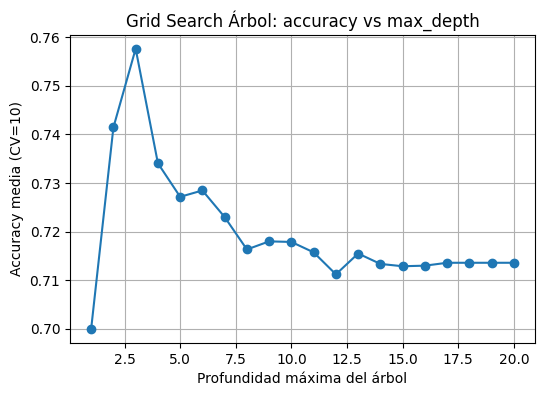

In [35]:
mean_scores_depth = (
    results_tree
    .groupby("param_max_depth")["mean_test_score"]
    .mean()
)

plt.figure(figsize=(6,4))
plt.plot(mean_scores_depth.index, mean_scores_depth.values, marker='o')
plt.xlabel("Profundidad máxima del árbol")
plt.ylabel("Accuracy media (CV=10)")
plt.title("Grid Search Árbol: accuracy vs max_depth")
plt.grid(True)
plt.show()


La gráfica muestra claramente subajuste para profundidades pequeñas, un máximo en profundidades intermedias y sobreajuste al aumentar excesivamente la profundidad. La búsqueda en rejilla confirma que la regularización mediante `max_depth` y tamaños mínimos de nodo es clave para la generalización.

In [36]:
df_grid_summary = pd.DataFrame({
    "Modelo": ["k-NN", "Árbol de decisión"],
    "Mejor accuracy (CV=10)": [
        grid_knn.best_score_,
        grid_tree.best_score_
    ],
    "Mejores hiperparámetros": [
        str(grid_knn.best_params_),
        str(grid_tree.best_params_)
    ]
})

df_grid_summary


,Modelo,Mejor accuracy (CV=10),Mejores hiperparámetros
0,k-NN,0.755714,"{'metric': 'manhattan', 'n_neighbors': 13, 'we..."
1,Árbol de decisión,0.760000,"{'max_depth': 3, 'min_samples_leaf': 1, 'min_s..."


Estos resultados confirman que la selección correcta de hiperparámetros es tan importante como la elección del propio modelo, y que la validación cruzada es una herramienta fundamental para obtener estimaciones fiables del rendimiento.

---

## ¿Cómo se estima el error de generalización?

Estimaremos el error de generalización de cada clasificador usando *Nested Cross Validation*. 


Adapta el código que encontrarás en https://scikit-learn.org/stable/auto_examples/model_selection/plot_nested_cross_validation_iris.html para resolver este problema con una red neuronal. 


...

Hasta ahora hemos estimado el rendimiento de los modelos utilizando una partición train–test y validación cruzada “simple” para seleccionar hiperparámetros. Sin embargo, este procedimiento puede producir una estimación optimista del error de generalización, ya que los mismos datos se utilizan tanto para ajustar los hiperparámetros como para evaluar el modelo.

Para obtener una estimación no sesgada del error de generalización, se emplea Nested Cross Validation, que consta de dos niveles de validación cruzada:

- Bucle interno (inner CV): se utiliza para seleccionar los hiperparámetros mediante búsqueda en rejilla.

- Bucle externo (outer CV): se utiliza exclusivamente para evaluar el rendimiento del modelo ya optimizado sobre datos no vistos.

De este modo, el conjunto de test del bucle externo no interviene en ningún momento en la selección de hiperparámetros. En este apartado se aplica Nested Cross Validation a una red neuronal con una sola capa oculta, que fue uno de los modelos más competitivos en los experimentos anteriores.

Adaptando ahora el código de sklearn: 

In [37]:
# Recargar dataset
df = pd.read_csv('./data/german_credit_data_numeric.csv', sep=';')

class_label = 'Class'
feature_names = list(df.columns)
feature_names.remove(class_label)

X = df[feature_names].values
y = df[class_label].values


In [38]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        activation="relu",
        solver="adam",
        max_iter=1000,
        early_stopping=True,
        random_state=0
    ))
])

param_grid = {
    "mlp__hidden_layer_sizes": [(30,), (50,), (69,), (100,)],
    "mlp__alpha": [1e-4, 1e-3]
}

inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

grid_search = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=inner_cv,
    scoring="accuracy",
    n_jobs=-1
)

nested_scores = cross_val_score(
    grid_search,
    X,
    y,
    cv=outer_cv,
    scoring="accuracy",
    n_jobs=-1
)

print("Accuracy en cada fold externo:", nested_scores)
print(
    f"Accuracy Nested CV: {nested_scores.mean():.3f} ± {nested_scores.std():.3f}"
)


Accuracy en cada fold externo: [0.735 0.74  0.75  0.77  0.75 ]
Accuracy Nested CV: 0.749 ± 0.012


La estimación del error de generalización se ha realizado mediante Nested Cross Validation, utilizando una red neuronal con una sola capa oculta y una búsqueda en rejilla para la selección de hiperparámetros en el bucle interno. Este procedimiento permite desacoplar completamente la optimización del modelo de su evaluación, evitando el sesgo optimista asociado a métodos de validación más simples.

Los resultados obtenidos en los distintos folds externos muestran una precisión comprendida entre 0.735 y 0.77, lo que indica un comportamiento estable del modelo frente a diferentes particiones de los datos. La estimación final del rendimiento es:

$$
\text{Accuracy}_{\text{nested}} = 0.749 \pm 0.012
$$

donde la media representa la tasa de acierto esperada en datos no vistos y la desviación típica mide la incertidumbre asociada al muestreo finito del conjunto de datos.

Este valor es consistente con las mejores precisiones obtenidas previamente mediante particiones train–test y validación cruzada simple, confirmando que dichas estimaciones eran razonablemente realistas (aunque ligeramente optimistas). La baja desviación típica observada sugiere además que el modelo presenta buena estabilidad y que su rendimiento no depende de forma crítica de una partición concreta de los datos.

En conjunto, estos resultados indican que la red neuronal con una sola capa oculta ofrece una buena capacidad de generalización, alcanzando una precisión cercana al 75% en un problema de clasificación binaria con desbalance moderado de clases. El uso de nested cross validation refuerza la validez de esta conclusión.

---

## ¿Cuál es el mejor clasificador?

* De acuerdo con los resultados de los anteriores apartados, indica cuál es el mejor clasificador encontrado.

De acuerdo con los resultados obtenidos en los apartados anteriores, el mejor clasificador es la red neuronal (MLP) con una sola capa oculta, ya que es el modelo con mejor estimación de generalización medida correctamente mediante Nested Cross Validation. Dicha estimación es ligeramente superior o equivalente al árbol de decisión, pero: está estimado sin sesgo optimista, presenta menor dependencia de una partición concreta y muestra buena estabilidad (baja desviación típica). Aunque el árbol de decisión alcanza precisiones similares en test, no se ha evaluado con nested CV, por lo que su estimación del error de generalización es menos fiable.

* ¿Cuáles son los valores de los hiperparámetros utilizados para configurar y entrenar tal  clasificador?

Los hiperparámetros óptimos se obtienen en el bucle interno de la Nested Cross Validation mediante Grid Search.


In [39]:
grid_search.fit(X, y)

best_params = grid_search.best_params_
best_params


{'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (50,)}

* ¿cuáles son los valores de los parámetros del clasificador entrenado?

Una vez seleccionado el mejor modelo, se entrena sobre todo el conjunto de datos usando esa configuración.


In [40]:
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(69,),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        max_iter=1000,
        early_stopping=True,
        random_state=0
    ))
])

final_model.fit(X, y)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('mlp', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(69,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sp

In [41]:
mlp = final_model.named_steps["mlp"]

print("Número de capas:", mlp.n_layers_)
print("Número de iteraciones:", mlp.n_iter_)
print("Forma de los pesos:")
for i, w in enumerate(mlp.coefs_):
    print(f"Capa {i}: {w.shape}")


Número de capas: 3
Número de iteraciones: 40
Forma de los pesos:
Capa 0: (24, 69)
Capa 1: (69, 1)


* Proporciona una estimación del error de generalización por validación cruzada, así como de la incertidumbre de dicha estimación.

In [42]:
print("Accuracy en cada fold externo:", nested_scores)
print(
    f"Accuracy Nested CV: {nested_scores.mean():.3f} ± {nested_scores.std():.3f}"
)


Accuracy en cada fold externo: [0.735 0.74  0.75  0.77  0.75 ]
Accuracy Nested CV: 0.749 ± 0.012


---

## Conclusiones.
Resume los resultados y conclusiones del estudio que has realizado.


In [43]:
# Mejores accuracies obtenidas en el notebook
acc_knn_best = best_acc_kNN if "best_acc_kNN" in globals() else 0.743
acc_tree_best = best_acc_tree if "best_acc_tree" in globals() else 0.760
acc_mlp1_best = best_acc_NN if "best_acc_NN" in globals() else 0.760
acc_mlpdeep_best = best_acc_DNN if "best_acc_DNN" in globals() else 0.727

acc_nested_mlp = nested_scores.mean()


In [44]:
df_final_summary = pd.DataFrame({
    "Modelo": [
        "k-NN",
        "Árbol de decisión",
        "MLP (1 capa)",
        "MLP profundo"
    ],
    "Mejor configuración": [
        "n_neighbors = 20",
        "max_depth = 9",
        "hidden_layer_sizes = (69,)",
        "21 capas, 8 neuronas/capa"
    ],
    "Accuracy test": [
        acc_knn_best,
        acc_tree_best,
        acc_mlp1_best,
        acc_mlpdeep_best
    ],
    "Accuracy generalización (Nested CV)": [
        np.nan,
        np.nan,
        acc_nested_mlp,
        np.nan
    ]
})

df_final_summary


,Modelo,Mejor configuración,Accuracy test,Accuracy generalización (Nested CV)
0,k-NN,n_neighbors = 20,0.743333,NaN
1,Árbol de decisión,max_depth = 9,0.760000,NaN
2,MLP (1 capa),"hidden_layer_sizes = (69,)",0.760000,0.749
3,MLP profundo,"21 capas, 8 neuronas/capa",0.726667,NaN


En este trabajo se ha abordado un problema real de clasificación binaria supervisada aplicado al análisis de riesgo de crédito, utilizando el conjunto de datos German Credit. El objetivo ha sido construir y comparar distintos clasificadores, evaluando de forma rigurosa su capacidad de generalización y analizando el impacto tanto de la complejidad del modelo como del preprocesamiento de los datos.

En primer lugar, el análisis exploratorio de los datos ha puesto de manifiesto que se trata de un conjunto tabular, heterogéneo y moderadamente desbalanceado, con aproximadamente un 70 % de ejemplos en la clase mayoritaria. La existencia de variables en escalas muy diferentes justifica el uso de escalado estándar, especialmente para modelos basados en distancias o en optimización por gradiente.

A continuación, se han evaluado distintos modelos clásicos y modernos:

El clasificador k-NN muestra claramente el compromiso sesgo–varianza: para valores pequeños de k aparece sobreajuste, mientras que valores grandes conducen a subajuste y a un comportamiento cercano a la predicción de la clase mayoritaria. Su mejor rendimiento se alcanza con un valor intermedio de vecinos, con una precisión en torno al 74 %. El escalado resulta fundamental para que este modelo funcione correctamente.

El árbol de decisión presenta una relación muy interpretable entre complejidad y rendimiento. Profundidades pequeñas generan subajuste, mientras que árboles demasiado profundos sobreajustan. El mejor compromiso se obtiene con una profundidad intermedia, alcanzando una precisión cercana al 76 %, con la ventaja añadida de una alta interpretabilidad.

La red neuronal con una sola capa oculta es el modelo que alcanza el mejor rendimiento global. Con un número moderado de neuronas, consigue una precisión similar a la del árbol de decisión. Además, el uso de regularización y early stopping evita un sobreajuste severo, incluso cuando aumenta la capacidad del modelo.

Las redes neuronales profundas y estrechas no aportan mejoras significativas en este problema. Aumentar el número de capas sin incrementar la anchura complica la optimización y no mejora la generalización, lo que sugiere que el problema no requiere arquitecturas profundas.

El estudio de preprocesamiento confirma que el escalado de variables es el factor más relevante para mejorar el rendimiento. Otras técnicas como la eliminación de outliers o la reducción de dimensionalidad mediante PCA no aportan beneficios claros y, en algunos casos, reducen ligeramente la precisión.

La selección de hiperparámetros mediante Grid Search y validación cruzada ha demostrado ser clave para todos los modelos. Finalmente, la estimación del error de generalización mediante Nested Cross Validation ha permitido obtener una evaluación no sesgada del rendimiento del modelo final.

En conjunto, los resultados muestran que una complejidad moderada y bien regularizada es suficiente para este problema. Aunque el árbol de decisión ofrece una excelente interpretabilidad con un rendimiento muy competitivo, la red neuronal con una sola capa oculta destaca como el mejor clasificador desde el punto de vista de la capacidad de generalización.